In [1]:
import sys
from pathlib import Path

print(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd().parent))

d:\ai-learning\neutrilen


In [2]:
import os 
from dotenv import load_dotenv

load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
USDA_API_KEY = os.getenv("USDA_API_KEY")
HF_TOKEN = os.getenv("HF_TOKEN")
DATABASE_URL = os.getenv("DATABASE_URL")

In [3]:
from db import get_user, fetch_goals, fetch_streak

USER_ID = "guest"

user   = get_user(USER_ID)
goals  = fetch_goals(USER_ID)
streak = fetch_streak(USER_ID)

print("User  :", dict(user))
print("Goals :", goals)
print("Streak:", dict(streak))

User  : {'id': 'guest', 'name': 'Guest', 'email': None, 'cal_goal': 2000, 'protein_g': 150, 'carbs_g': 200, 'fat_g': 65, 'diet_type': 'maintain', 'units': 'metric', 'created_at': datetime.datetime(2026, 6, 5, 9, 7, 12, 855482, tzinfo=datetime.timezone.utc), 'updated_at': datetime.datetime(2026, 6, 5, 9, 7, 12, 855482, tzinfo=datetime.timezone.utc)}
Goals : {'calories': 2000, 'protein': 150, 'carbs': 200, 'fat': 65}
Streak: {'user_id': 'guest', 'current': 0, 'longest': 0, 'last_log': None, 'badge_3': False, 'badge_7': False, 'badge_14': False, 'badge_30': False}


In [4]:
from typing import TypedDict, Optional
from pydantic import BaseModel

class NutritionEntry(BaseModel):
    food_name: str
    portion_g:  Optional[float] = None
    calories:   float
    protein:    float
    carbs:      float
    fat:        float
    confidence: float = 1.0
    source:     str   = "groq"

class AgentState(TypedDict):
    user_id:           str
    image_b64:         Optional[str]
    raw_vision_text:   str
    nutrition_entries: list[NutritionEntry]
    daily_total:       dict
    goals:             dict
    streak:            int
    advice:            str
    error:             Optional[str]

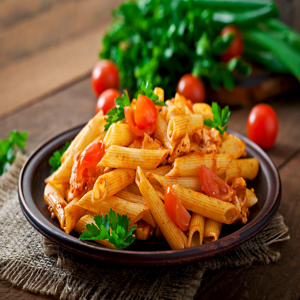

Base64 length: 178,992 chars


In [5]:
from PIL import Image
import io
from IPython.display import display
import base64

IMAGE_PATH = "test.jpg"

def load_image_b64(path: str, max_px: int = 1024) -> str:
    img = Image.open(path).convert("RGB")
    w, h = img.size
    if max(w, h) > max_px:
        scale = max_px / max(w, h)
        img   = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=85)
    return base64.b64encode(buf.getvalue()).decode("utf-8")

image_b64 = load_image_b64(IMAGE_PATH)
display(Image.open(IMAGE_PATH).resize((300, 300)))
print(f"Base64 length: {len(image_b64):,} chars")

In [6]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

d:\ai-learning\neutrilen\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
VISION_PROMPT = """
You are an expert nutritionist and Indian food analyst.

Analyse this food image in extreme detail. 

CRITICAL RULES:
- NEVER use "Vegetable Curry" or any generic dish name as a food item
- ALWAYS break every dish down to its individual ingredients
- Look inside each bowl carefully and identify every visible ingredient
- If a curry has potatoes, tomatoes, peas — list each one separately
- If dal has ghee on top — list dal and ghee separately
- Sambar should be broken into its vegetables and lentil base separately

For the vegetable curry bowl specifically:
- Look for: potato cubes, tomato pieces, green peas, capsicum, eggplant, curry leaves, onion, any other visible vegetables
- List EACH vegetable as its own entry

Return ONLY valid JSON — no markdown, no explanation:

{
  "dish_name": "string",
  "cuisine": "string", 
  "foods": [
    {
      "name":       "string",
      "role":       "string",
      "portion_g":  integer,
      "calories":   integer,
      "protein":    float,
      "carbs":      float,
      "fat":        float,
      "confidence": float
    }
  ],
  "total_calories":  integer,
  "analysis_notes":  "string"
}

Field rules:
- "name"       : SPECIFIC ingredient only — "potato cubes", "green peas", "curry leaves" NEVER generic names like "vegetable curry" or "mixed vegetables"
- "role"       : "carb" | "protein" | "vegetable" | "lentil" | "fat" | "sauce" | "garnish"
- "portion_g"  : estimated grams of that specific ingredient
- "confidence" : 0.0–1.0, lower if hidden under sauce or hard to see clearly

Looking at this image I can see:
- A thali (steel plate) with roti, rice, and 3 bowls
- Top right bowl: vegetable curry — look carefully for individual vegetables
- Bottom left bowl: dal with ghee
- Bottom right bowl: sambar with vegetables

Break ALL of these down to individual ingredients.
"""

In [8]:
vision_llm = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    api_key=GROQ_API_KEY,
    max_tokens=1024,
    temperature=0.1
)

In [9]:
def vision_node(state: AgentState):
    print("Running vision Node...")
    try:
        msg = HumanMessage(content=[
            {"type": "text", "text": VISION_PROMPT},
            {"type": "image_url", "image_url": {
                "url": f"data:image/jpeg;base64,{state['image_b64']}"
            }},
        ])
        response = vision_llm.invoke([msg])
        raw = response.content.strip()
        if raw.startswith("```"):
            raw = raw.split("```")[1]
            if raw.startswith("json"):
                raw = raw[4:]
        print("✅  Vision node complete")
        return {"raw_vision_text": raw.strip(), "error": None}
    except Exception as e:
        print(f"❌  Vision node failed: {e}")
        return {"raw_vision_text": "", "error": str(e)}

In [10]:
import json

test_state: AgentState = {
    "user_id":           USER_ID,
    "image_b64":         image_b64,
    "raw_vision_text":   "",
    "nutrition_entries": [],
    "daily_total":       {},
    "goals":             fetch_goals(USER_ID),
    "streak":            0,
    "advice":            "",
    "error":             None,
}

vision_result = vision_node(test_state)
test_state.update(vision_result)

Running vision Node...
✅  Vision node complete


In [11]:
print("\nRaw Groq response:")
print(json.dumps(json.loads(test_state["raw_vision_text"]), indent=2))


Raw Groq response:
{
  "dish_name": "Pasta with Tomato Sauce",
  "cuisine": "Italian",
  "foods": [
    {
      "name": "penne pasta",
      "role": "carb",
      "portion_g": 200,
      "calories": 250,
      "protein": 0.9,
      "carbs": 50.0,
      "fat": 1.0,
      "confidence": 0.9
    },
    {
      "name": "tomato pieces",
      "role": "vegetable",
      "portion_g": 100,
      "calories": 20,
      "protein": 0.9,
      "carbs": 4.0,
      "fat": 0.2,
      "confidence": 0.8
    },
    {
      "name": "parsley leaves",
      "role": "garnish",
      "portion_g": 10,
      "calories": 1,
      "protein": 0.1,
      "carbs": 0.2,
      "fat": 0.0,
      "confidence": 0.8
    }
  ],
  "total_calories": 271,
  "analysis_notes": "The image appears to be a pasta dish with tomato sauce, not Indian cuisine."
}


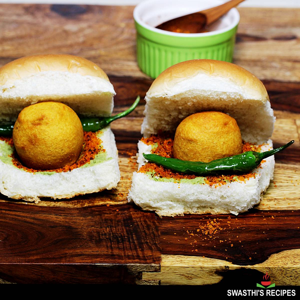

Base64 length: 283,528 chars
Running vision Node...
✅  Vision node complete

Raw Groq response:
{
  "dish_name": "Vada Pav",
  "cuisine": "Indian",
  "foods": [
    {
      "name": "Pav",
      "role": "carb",
      "portion_g": 200,
      "calories": 200,
      "protein": 3.5,
      "carbs": 40,
      "fat": 2,
      "confidence": 0.9
    },
    {
      "name": "Vada",
      "role": "protein",
      "portion_g": 100,
      "calories": 150,
      "protein": 5,
      "carbs": 20,
      "fat": 8,
      "confidence": 0.8
    },
    {
      "name": "Green Chili",
      "role": "garnish",
      "portion_g": 20,
      "calories": 10,
      "protein": 0.5,
      "carbs": 2,
      "fat": 0,
      "confidence": 0.8
    },
    {
      "name": "Chutney",
      "role": "sauce",
      "portion_g": 20,
      "calories": 20,
      "protein": 0.5,
      "carbs": 5,
      "fat": 0,
      "confidence": 0.5
    },
    {
      "name": "Masala",
      "role": "garnish",
      "portion_g": 10,
      "calori

In [12]:
import json

IMAGE_PATH = "vada-pav.jpg"
image_b64 = load_image_b64(IMAGE_PATH)
display(Image.open(IMAGE_PATH).resize((300, 300)))
print(f"Base64 length: {len(image_b64):,} chars")

test_state: AgentState = {
    "user_id":           USER_ID,
    "image_b64":         image_b64,
    "raw_vision_text":   "",
    "nutrition_entries": [],
    "daily_total":       {},
    "goals":             fetch_goals(USER_ID),
    "streak":            0,
    "advice":            "",
    "error":             None,
}

vision_result = vision_node(test_state)
test_state.update(vision_result)
print("\nRaw Groq response:")
print(json.dumps(json.loads(test_state["raw_vision_text"]), indent=2))